<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Genesis005_3d.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

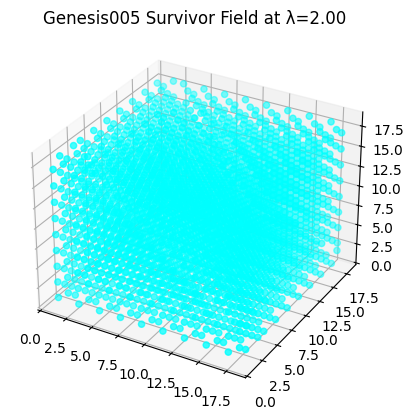

Survivor λ values: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.7999999999999999), np.float64(0.8999999999999999), np.float64(0.9999999999999999), np.float64(1.0999999999999999)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Lattice size
N = 20
timesteps = 50
threshold = 0.1  # Collapse threshold

# Initialize scalar field and mass field
s = np.zeros((N, N, N))
m = np.ones((N, N, N))  # Uniform mass for now

# Seed pure hotspots (no attractors)
hotspots = [(10, 10, 10), (5, 5, 5), (15, 15, 15)]
for x, y, z in hotspots:
    s[x, y, z] = 1.0

# Genesis004 update rule in 3D
def update(s, λ):
    s_new = np.copy(s)
    for x in range(1, N-1):
        for y in range(1, N-1):
            for z in range(1, N-1):
                neighbors = (
                    s[x+1,y,z] + s[x-1,y,z] +
                    s[x,y+1,z] + s[x,y-1,z] +
                    s[x,y,z+1] + s[x,y,z-1]
                )
                s_new[x,y,z] += λ * (neighbors / 6 - s[x,y,z])
    return s_new

# Sweep λ and track survivors
λ_values = np.linspace(0.1, 2.0, 20)
survivors = []

for λ in λ_values:
    s_temp = np.copy(s)
    for t in range(timesteps):
        s_temp = update(s_temp, λ)
    total_energy = np.sum(s_temp)
    if total_energy > threshold:
        survivors.append(λ)

# Visualize final survivor field
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x, y, z = np.where(s_temp > threshold)
ax.scatter(x, y, z, c='cyan', marker='o')
plt.title(f"Genesis005 Survivor Field at λ={λ:.2f}")
plt.show()

# Print survivor λ values
print("Survivor λ values:", survivors)
